# Guess the suit of a random card: TypeLLM API vs OpenAI Decisions API

Both APIs are asked the same question: a card is drawn at random from a standard deck; what is its suit?
The truth is 1 in 4 for each suit. Each returns a probability for every suit, and the two then bet against
each other: the side whose probabilities are closer to the truth wins the money over time.

Paste your TypeLLM and OpenAI API keys in the cell below, then run all cells.

In [1]:
%pip install -q "typellm>=0.6.7" "openai>=3.26" matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Paste your API keys here.
TYPELLM_API_KEY = ""  # https://typellm.ai/dashboard/keys
OPENAI_API_KEY  = ""  # https://platform.openai.com/api-keys

In [3]:
import math
import random

import matplotlib.pyplot as plt
from openai import OpenAI
from typellm import TypeLLMClient

typellm = TypeLLMClient(api_key=TYPELLM_API_KEY)
openai = OpenAI(api_key=OPENAI_API_KEY)

## Ask both APIs

The same context and question go to each. `return_probabilities` gives TypeLLM's probability for every suit;
the Decisions API returns its probabilities with every choice.

In [4]:
CONTEXT = "One card was drawn at random from a well-shuffled standard 52-card deck. It has not been looked at."
QUESTION = "What is the suit of the card?"
SUITS = ["hearts", "diamonds", "clubs", "spades"]
TRUTH = {suit: 0.25 for suit in SUITS}

response = typellm.generate(context=CONTEXT, questions={"suit": {
    "type": "string", "enum": SUITS, "instructions": QUESTION, "return_probabilities": True}})
typellm_probs = {k: float(v) for k, v in response.result["suit"]["probabilities"].items()}

decision = openai.decisions.create(model="gpt-6-luna", input=CONTEXT, questions=[{
    "type": "choice", "name": "suit", "instructions": QUESTION, "choices": [{"value": s} for s in SUITS]}])
openai_probs = {p.value: float(p.probability) for p in decision.answers[0].probabilities}

print(f"{'suit':10s}{'truth':>8s}{'TypeLLM':>10s}{'OpenAI':>10s}")
for suit in SUITS:
    print(f"{suit:10s}{TRUTH[suit]:8.2f}{typellm_probs[suit]:10.3f}{openai_probs.get(suit, 0):10.3f}")

suit         truth   TypeLLM    OpenAI
hearts        0.25     0.236     0.860
diamonds      0.25     0.185     0.060
clubs         0.25     0.200     0.070
spades        0.25     0.378     0.010


## How close to the truth

KL divergence from the true distribution: 0 is a perfect match, lower is better. Probabilities are floored at
0.001 and renormalised on both sides, so a zero cannot end the game in one round.

In [5]:
FLOOR = 0.001

def floored(probs):
    q = {s: max(probs.get(s, 0.0), FLOOR) for s in SUITS}
    total = sum(q.values())
    return {s: v / total for s, v in q.items()}

forecasts = {"TypeLLM": floored(typellm_probs), "OpenAI": floored(openai_probs)}
for name, q in forecasts.items():
    kl = sum(TRUTH[s] * math.log(TRUTH[s] / q[s]) for s in SUITS)
    print(f"{name:8s} KL {kl:.3f}")

TypeLLM  KL 0.041
OpenAI   KL 1.171


## Bet

The two put in equal money. Each round a card is drawn at random, and a share `STAKE` of each side's money is
re-split in proportion to the probability each gave the suit that came up. Over many rounds, the side whose
probabilities are closer to the truth ends up with the pool. `STAKE` only sets how fast that happens.

In [6]:
ROUNDS, STAKE, SEED = 100, 0.1, 7

rng = random.Random(SEED)
share = 0.5  # TypeLLM's share of the pool
curve = [share]
for n in range(1, ROUNDS + 1):
    suit = rng.choice(SUITS)
    a, b = forecasts["TypeLLM"][suit], forecasts["OpenAI"][suit]
    share = (1 - STAKE) * share + STAKE * share * a / (share * a + (1 - share) * b)
    curve.append(share)
    if n <= 5:
        print(f"round {n}: {suit:8s} TypeLLM {a:.3f}  OpenAI {b:.3f}  -> TypeLLM holds {share:.1%}")

for n in (10, 50, ROUNDS):
    print(f"after {n} rounds: TypeLLM holds {curve[n]:.1%} of the pool")

round 1: clubs    TypeLLM 0.200  OpenAI 0.070  -> TypeLLM holds 52.4%
round 2: diamonds TypeLLM 0.185  OpenAI 0.060  -> TypeLLM holds 54.9%
round 3: spades   TypeLLM 0.378  OpenAI 0.010  -> TypeLLM holds 59.2%
round 4: hearts   TypeLLM 0.236  OpenAI 0.860  -> TypeLLM holds 56.1%
round 5: hearts   TypeLLM 0.236  OpenAI 0.860  -> TypeLLM holds 53.1%
after 10 rounds: TypeLLM holds 49.3% of the pool
after 50 rounds: TypeLLM holds 78.0% of the pool
after 100 rounds: TypeLLM holds 93.2% of the pool


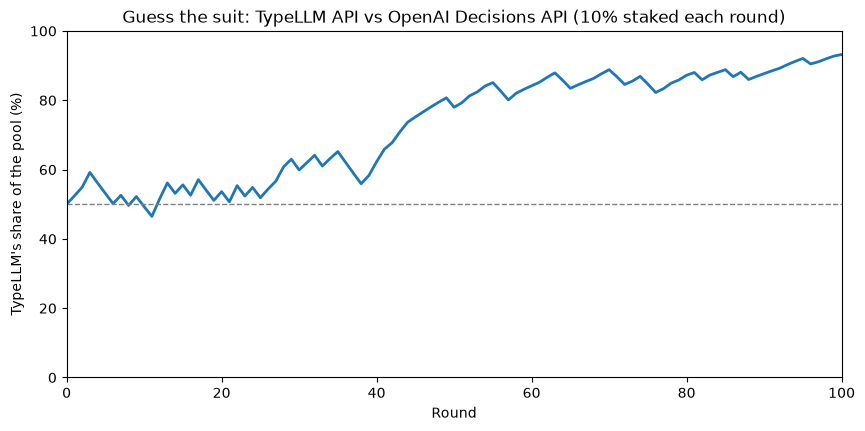

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(len(curve)), [100 * c for c in curve], lw=2)
ax.axhline(50, color="gray", lw=1, ls="--")
ax.set_ylim(0, 100)
ax.set_xlim(0, ROUNDS)
ax.set_xlabel("Round")
ax.set_ylabel("TypeLLM's share of the pool (%)")
ax.set_title(f"Guess the suit: TypeLLM API vs OpenAI Decisions API ({int(STAKE * 100)}% staked each round)")
plt.show()